In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import requests
import io
import logging
import re
import os
import json
from datetime import datetime, timedelta

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')


### 1. Carregar o Dataset

In [71]:
url = "https://www.bcb.gov.br/pda/desig/desenrola/dados_desenrola.csv"
local_file = "../data/raw/dados_desenrola.csv"
csv_config_br = {"sep": ";", "decimal": ",", "encoding": "utf-8"}

def extract_data(url: str, local_file: str, csv_config: dict) -> pd.DataFrame:
    """"
    Tenta baixar o dataset de uma URL. Se falhar, tenta carregar de um arquivo local.
    Argumentos: url (str): URL para baixar o dataset.
                local_file (str): Caminho do arquivo local como fallback.
                csv_config (dict): Configurações para leitura do CSV.
    Retorna:    pd.DataFrame: DataFrame contendo os dados extraídos.
    """
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    try:
        logging.info("Tentando baixar o dataset online...")
        response = requests.get(url, headers=headers, timeout=15)
        response.raise_for_status()
        logging.info("Download bem-sucedido. Carregando os dados...")
        df = pd.read_csv(
            io.StringIO(response.text),
            **csv_config
            )
        logging.info(f"Dados extraídos com sucesso da internet. [{len(df)}] registros encontrados.")
    except Exception as e:
        logging.error(f"Não foi possível baixar da internet. Motivo: {e}")
        logging.info("Utilizando arquivo local como alternativa...")
        df = pd.read_csv(
            local_file,
            **csv_config
            )
        logging.info(f"Dados extraídos com sucesso de arquivo local. [{len(df)}] registros encontrados.")
    return df

df_raw = extract_data(url, local_file, csv_config_br)
df_raw.info()


INFO - Tentando baixar o dataset online...
INFO - Download bem-sucedido. Carregando os dados...
INFO - Dados extraídos com sucesso da internet. [10598] registros encontrados.


<class 'pandas.DataFrame'>
RangeIndex: 10598 entries, 0 to 10597
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   DATA_BASE                     10598 non-null  int64  
 1   TIPO_DESENROLA                10598 non-null  int64  
 2   UNIDADE_FEDERACAO             10598 non-null  str    
 3   COD_CONGLOMERADO_FINANCEIRO   10598 non-null  int64  
 4   NOME_CONGLOMERADO_FINANCEIRO  10598 non-null  str    
 5   NUMERO_OPERACOES              10598 non-null  int64  
 6   VOLUME_OPERACOES              10598 non-null  float64
dtypes: float64(1), int64(4), str(2)
memory usage: 579.7 KB


#### 1.5 Sujar o Dataset para limpeza posterior

In [72]:
def dirty_data(df, noise_level=0.02) -> pd.DataFrame:
    """"
    Gera uma versão "suja" a partir de um dataframe. Adiciona valores nulos, strings com espaços, datas inválidas, valores extremos e valores duplicados ao final do dataframe.
    Argumentos: df (pd.DataFrame): DataFrame original.
                noise_level (float): Proporção de registros a serem corrompidos para cada tipo de corrupção (padrão: 2%).
    Retorna:    pd.DataFrame: DataFrame "sujo" com as corrupções introduzidas.
    """
    df_clean = df.copy()
    corrupted_rows = []
    
    # Introduz valores nulos
    df_nulls = df_clean.sample(frac=noise_level).copy()
    for col in df_nulls.columns:
        df_nulls.loc[df_nulls.sample(frac=0.5).index, col] = np.nan
    corrupted_rows.append(df_nulls)
    logging.info(f"Introduzidos valores nulos em {len(df_nulls)} registros.")
    
    # Introduz espaços em branco em colunas de texto
    df_text_columns = df_clean.select_dtypes(include=['object', 'string']).columns
    if not df_text_columns.empty:
        df_spaces = df_clean.sample(frac=noise_level).copy()
        for col in df_text_columns:
            df_spaces[col] = '   ' + df_spaces[col].astype(str) + '   '
        corrupted_rows.append(df_spaces)
        logging.info(f"Introduzidos espaços em branco em {len(df_spaces)} registros.")

    # Introduz datas inválidas
    df_dates = df_clean.sample(frac=noise_level).copy()
    df_dates['DATA_BASE'] = 'invalid_date'
    corrupted_rows.append(df_dates)
    logging.info(f"Introduzidas datas inválidas em {len(df_dates)} registros.")

    # Introduz outliers em colunas numéricas
    numeric_columns = df_clean.select_dtypes(include=np.number).columns
    if not numeric_columns.empty:
        df_outliers = df_clean.sample(frac=noise_level).copy()
        for column in numeric_columns:
            df_outliers[column] = df_clean[column].max() * 10
        corrupted_rows.append(df_outliers)
        logging.info(f"Introduzidos outliers em {len(df_outliers)} registros.")

    # Introduz duplicatas
    df_duplicates = df_clean.sample(frac=noise_level).copy()
    corrupted_rows.append(df_duplicates)
    logging.info(f"Introduzidas duplicatas em {len(df_duplicates)} registros.")

    df_dirty = pd.concat([df_clean] + corrupted_rows, ignore_index=True)

    # Converte as colunas de inteiros para Int64 para permitir valores nulos, mantendo a consistência de tipo com o dataframe original.
    int_cols = df_clean.select_dtypes(include='int64').columns
    int_cols = [col for col in int_cols if col != 'DATA_BASE'] # Filtra e remove a coluna de data
    for col in int_cols:
        df_dirty[col] = df_dirty[col].astype('Int64')

    return df_dirty

df_dirty = dirty_data(df_raw)
logging.info(f"Dataset sujo criado com sucesso. Total de registros: {len(df_dirty)}")
os.makedirs("../data/raw", exist_ok=True)
df_dirty.to_csv("../data/raw/desenrola_sujo.csv", index=False)
logging.info("Dataset sujo salvo em '../data/raw/")
print(df_dirty.tail())


INFO - Introduzidos valores nulos em 212 registros.
INFO - Introduzidos espaços em branco em 212 registros.
INFO - Introduzidas datas inválidas em 212 registros.
INFO - Introduzidos outliers em 212 registros.
INFO - Introduzidas duplicatas em 212 registros.
INFO - Dataset sujo criado com sucesso. Total de registros: 11658
INFO - Dataset sujo salvo em '../data/raw/


      DATA_BASE  TIPO_DESENROLA UNIDADE_FEDERACAO  \
11653    202403               1                BA   
11654    202512               1                BA   
11655    202506               1                SP   
11656    202406               2                MG   
11657    202403               1                BA   

       COD_CONGLOMERADO_FINANCEIRO NOME_CONGLOMERADO_FINANCEIRO  \
11653                        51750                 BANCO SICOOB   
11654                        80336     BTG PACTUAL - PRUDENCIAL   
11655                        80329              BB - PRUDENCIAL   
11656                        51626      CAIXA ECONÔMICA FEDERAL   
11657                        51011                   VOTORANTIM   

       NUMERO_OPERACOES  VOLUME_OPERACOES  
11653                 9          17457.20  
11654                 1            200.09  
11655                 2            350.08  
11656                 1            161.72  
11657                11          24821.98  


### 2. Inspecionar o Dataset

In [73]:
def inspect_data(df):
    """
    Realiza uma inspeção básica do dataset, exibindo shape, colunas, tipos de dados, valores nulos, primeiros registros e estatísticas descritivas.
    Argumentos: df (pd.DataFrame): DataFrame a ser inspecionado.
    Retorna:    pd.DataFrame: Estatísticas descritivas do DataFrame.
    """
    print ("\n=== INSPEÇÃO DO DATASET ===")
    print (f"Shape: {df.shape}")
    print (f"\nColunas: {list(df.columns)}")
    print (f"\nTipos de dados:\n{df.dtypes}")
    print (f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print (f"\nPrimeiros registros:\n{df.head()}")
    print (f"\nEstatísticas descritivas:\n{df.describe()}")
    return df.describe(include= "all" )

inspect_data(df_dirty)


=== INSPEÇÃO DO DATASET ===
Shape: (11658, 7)

Colunas: ['DATA_BASE', 'TIPO_DESENROLA', 'UNIDADE_FEDERACAO', 'COD_CONGLOMERADO_FINANCEIRO', 'NOME_CONGLOMERADO_FINANCEIRO', 'NUMERO_OPERACOES', 'VOLUME_OPERACOES']

Tipos de dados:
DATA_BASE                        object
TIPO_DESENROLA                    Int64
UNIDADE_FEDERACAO                   str
COD_CONGLOMERADO_FINANCEIRO       Int64
NOME_CONGLOMERADO_FINANCEIRO        str
NUMERO_OPERACOES                  Int64
VOLUME_OPERACOES                float64
dtype: object

Valores nulos por coluna:
DATA_BASE                       106
TIPO_DESENROLA                  106
UNIDADE_FEDERACAO               106
COD_CONGLOMERADO_FINANCEIRO     106
NOME_CONGLOMERADO_FINANCEIRO    106
NUMERO_OPERACOES                106
VOLUME_OPERACOES                106
dtype: int64

Primeiros registros:
  DATA_BASE  TIPO_DESENROLA UNIDADE_FEDERACAO  COD_CONGLOMERADO_FINANCEIRO  \
0    202309               2                AC                        49906   
1    2

,DATA_BASE,TIPO_DESENROLA,UNIDADE_FEDERACAO,COD_CONGLOMERADO_FINANCEIRO,NOME_CONGLOMERADO_FINANCEIRO,NUMERO_OPERACOES,VOLUME_OPERACOES
count,11552.0,11552.0,11552,11552.0,11552,11552.0,1.155200e+04
unique,34.0,<NA>,54,<NA>,106,<NA>,NaN
top,202311.0,<NA>,SP,<NA>,BRADESCO,<NA>,NaN
freq,731.0,<NA>,629,<NA>,986,<NA>,NaN
mean,NaN,2.056787,NaN,16952201.172005,NaN,8766.888158,4.021005e+07
std,NaN,3.885478,NaN,116632550.173332,NaN,62246.060116,2.888906e+08
min,NaN,1.0,NaN,10045.0,NaN,1.0,1.000000e-02
25%,NaN,1.0,NaN,30379.0,NaN,2.0,1.191715e+03
50%,NaN,1.0,NaN,51750.0,NaN,9.0,1.912708e+04
75%,NaN,2.0,NaN,80185.0,NaN,90.0,2.940743e+05


### 3. Limpar e Tratar os Dados

In [74]:
def normalize_string(text):
    """
    Função auxiliar para normalizar espaços em branco em uma string, preservando valores nulos.
    Argumentos: text (str): String a ser normalizada.
    Retorna:    str: String normalizada.
    """
    if pd.isna(text):
        return text
    cleaned_text = str(text)
    cleaned_text = re.sub(r"\s+", " ", cleaned_text)
    return cleaned_text.strip()

def clean_strings(df, columns):
    """
    Limpa strings em colunas espcíficas, normalizando espaços em branco e preservando valores nulos.
    Argumentos: df (pd.DataFrame): DataFrame a ser limpo.
                columns (list): Lista de nomes de colunas a serem limpas.
    Retorna:    pd.DataFrame: DataFrame com as colunas limpas.
    """
    df = df.copy()
    for column in columns:
        df[column] = df[column].apply(lambda cell: normalize_string(cell))
    return df

def clean_dates(df, columns, format='%Y%m'):
    """
    Converte colunas de data para o tipo datetime. Datas inválidas serão convertidas para NaT (Not a Time).
    O formato de data esperado é 'YYYYMM', seguindo o formato presente no dataset original.
    Argumentos: df (pd.DataFrame): DataFrame a ser limpo.
                columns (list): Lista de nomes de colunas de data a serem limpas.
                format (str): Formato de data esperado.
    Retorna:    pd.DataFrame: DataFrame com as colunas de data limpas.
    """
    df = df.copy()
    for column in columns:
        df[column] = pd.to_datetime(df[column], format=format, errors='coerce')
    return df

def fill_missing_institution_names(df):
    """"
    Função auxiliar para preencher os valores nulos na coluna de nome do conglomerado financeiro usando o código do conglomerado financeiro como referência, já que cada código corresponde a uma instituição financeira específica. (imputação baseada em mapeamento).
    Argumentos: df (pd.DataFrame): DataFrame a ser limpo.
    Retorna:    pd.DataFrame: DataFrame com os nomes do conglomerado financeiro preenchidos onde possível.
    """
    mapping = (
        df.dropna(subset=["NOME_CONGLOMERADO_FINANCEIRO"])
        .drop_duplicates(subset=["COD_CONGLOMERADO_FINANCEIRO"])
        .set_index("COD_CONGLOMERADO_FINANCEIRO")["NOME_CONGLOMERADO_FINANCEIRO"]
        .to_dict()
        )
    replacement_values = df["COD_CONGLOMERADO_FINANCEIRO"].map(mapping)
    df["NOME_CONGLOMERADO_FINANCEIRO"] = df["NOME_CONGLOMERADO_FINANCEIRO"].fillna(replacement_values)
    return df

def clean_data(df):
    """
    Função principal de limpeza de dados, que chama as funções auxiliares, realiza outras remoções de dados inválidos ou desnecessários e configura os tipos de dados.
    Argumentos: df (pd.DataFrame): DataFrame a ser limpo.
    Retorna:    pd.DataFrame: DataFrame limpo.
    """
    df = df.copy()
    report = {}
    report["registros_iniciais"] = len(df)

    # Etapa 1: Limpa strings em colunas de texto.
    df = clean_strings(df, ["UNIDADE_FEDERACAO", "NOME_CONGLOMERADO_FINANCEIRO"])

    # Etapa 2: Converte a coluna de data para o tipo datetime e remove linhas sem data válida.
    df = clean_dates(df, ["DATA_BASE"])
    before = len(df)
    df = df.dropna(subset=["DATA_BASE"])
    report["datas_invalidas_removidas"] = before - len(df)

    # Etapa 3: Remove tipos do programa inválidos.
    # Só existem 3 tipos no programa Desenrola Brasil (1, 2 e 3); valores fora disso são inválidos.
    before = len(df)
    df = df[df["TIPO_DESENROLA"].isin([1, 2, 3])]
    report["tipos_invalidos_removidos"] = before - len(df)

    # Etapa 4: Preenche os valores nulos na coluna de nome do conglomerado financeiro.
    before_names = df["NOME_CONGLOMERADO_FINANCEIRO"].isna().sum()
    df = fill_missing_institution_names(df)
    after_names = df["NOME_CONGLOMERADO_FINANCEIRO"].isna().sum()
    report["nomes_instituicao_preenchidos"] = before_names - after_names

    # Etapa 4: Remove a coluna código do conglomerado financeiro, pois é redundante com o nome da instituição financeira.
    df = df.drop(columns=["COD_CONGLOMERADO_FINANCEIRO"])
   
    # Etapa 5: Remove registros restantes que ainda tenham valores nulos
    before = len(df)
    df = df.dropna()
    report["nulos_removidos"] = before - len(df)

    # Etapa 6: Remove registros duplicados
    before = len(df)
    df = df.drop_duplicates()
    report["registros_duplicados_removidos"] = before - len(df)

    # Etapa 7: Define tipos de dados corretos para colunas categóricas
    df["UNIDADE_FEDERACAO"] = df["UNIDADE_FEDERACAO"].astype("category")
    df["TIPO_DESENROLA"] = df["TIPO_DESENROLA"].astype("category")

    report["registros_finais"] = len(df)
    report["registros_removidos_total"] = report["registros_iniciais"] - len(df)

    print ("\n=== RELATÓRIO DE LIMPEZA DE DADOS ===")
    for etapa, valor in report.items():
        print(f"  {etapa}: {valor}")

    return df, report

df_v1, report = clean_data(df_dirty)

os.makedirs("../data/processed", exist_ok=True)
df_v1.to_csv("../data/processed/desenrola_v1.csv", index=False)
print("\nv1 salva em ../data/processed/")


=== RELATÓRIO DE LIMPEZA DE DADOS ===
  registros_iniciais: 11658
  datas_invalidas_removidas: 530
  tipos_invalidos_removidos: 50
  nomes_instituicao_preenchidos: 14
  nulos_removidos: 52
  registros_duplicados_removidos: 428
  registros_finais: 10598
  registros_removidos_total: 1060

v1 salva em ../data/processed/


### 4. Tratar Outliers


=== INSPEÇÃO DO DATASET ===
Shape: (10598, 6)

Colunas: ['DATA_BASE', 'TIPO_DESENROLA', 'UNIDADE_FEDERACAO', 'NOME_CONGLOMERADO_FINANCEIRO', 'NUMERO_OPERACOES', 'VOLUME_OPERACOES']

Tipos de dados:
DATA_BASE                       datetime64[us]
TIPO_DESENROLA                        category
UNIDADE_FEDERACAO                     category
NOME_CONGLOMERADO_FINANCEIRO               str
NUMERO_OPERACOES                         Int64
VOLUME_OPERACOES                       float64
dtype: object

Valores nulos por coluna:
DATA_BASE                       0
TIPO_DESENROLA                  0
UNIDADE_FEDERACAO               0
NOME_CONGLOMERADO_FINANCEIRO    0
NUMERO_OPERACOES                0
VOLUME_OPERACOES                0
dtype: int64

Primeiros registros:
   DATA_BASE TIPO_DESENROLA UNIDADE_FEDERACAO NOME_CONGLOMERADO_FINANCEIRO  \
0 2023-09-01              2                AC                           BB   
1 2023-09-01              2                AC                     BRADESCO   
2 202

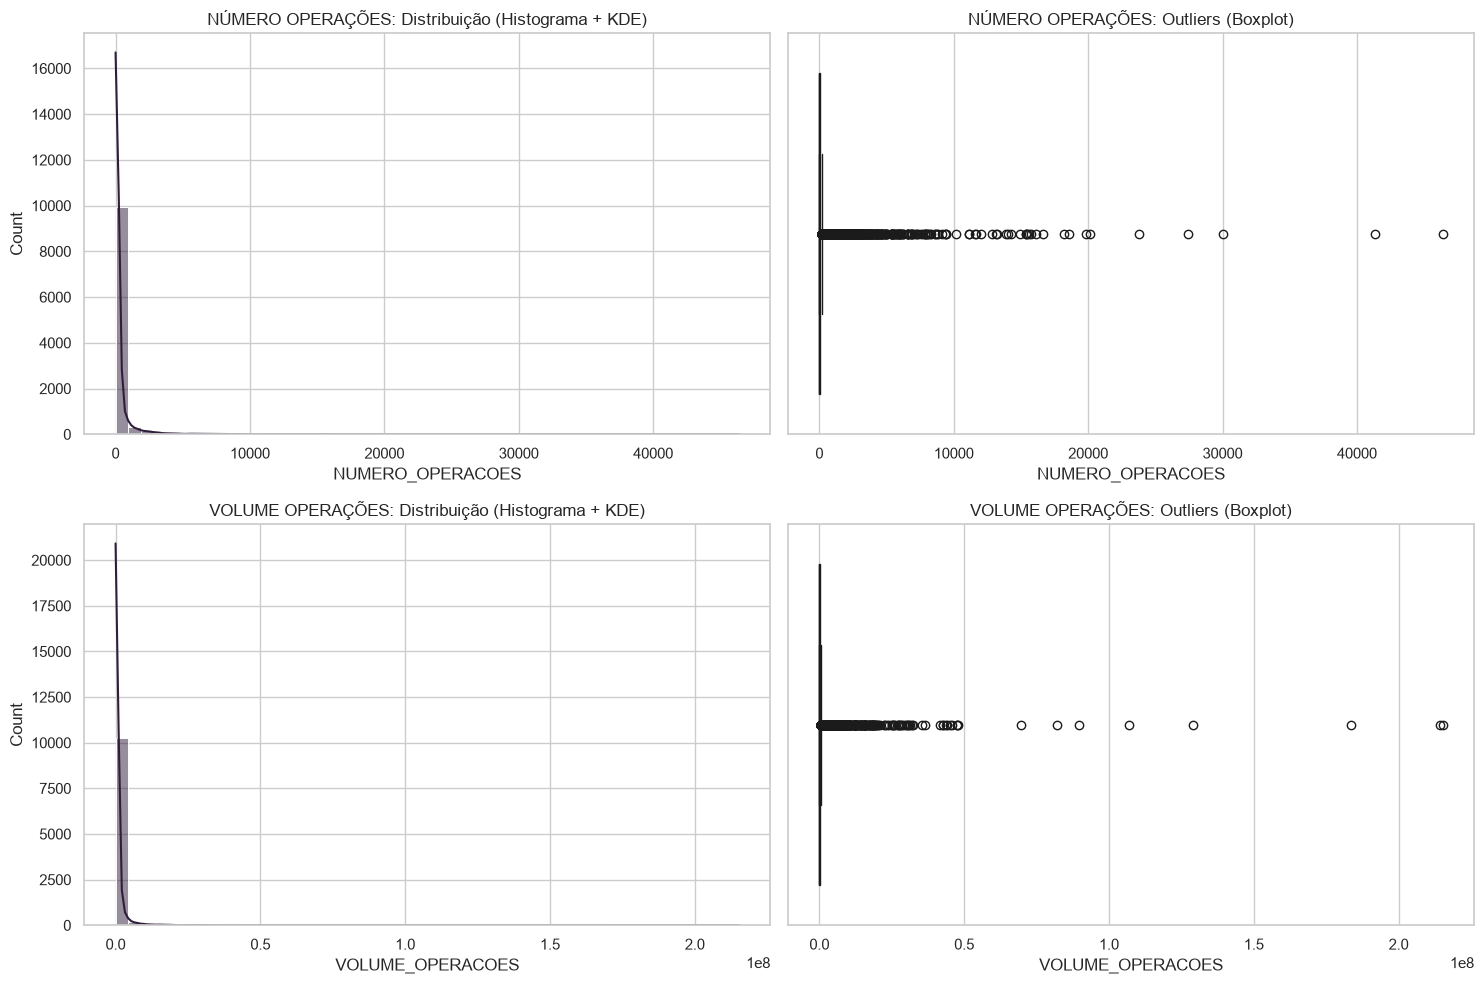

In [75]:
# Vamos olhar mais uma vez o dataset limpo para entender melhor os dados antes de tratar os outliers.
inspect_data(df_v1)

# Visualização da distribuição das colunas numéricas:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(data=df_v1, x="NUMERO_OPERACOES", kde=True, bins=50, ax=axes[0, 0])
axes[0, 0].set_title("NÚMERO OPERAÇÕES: Distribuição (Histograma + KDE)")

sns.boxplot(data=df_v1, x="NUMERO_OPERACOES", ax=axes[0, 1])
axes[0, 1].set_title("NÚMERO OPERAÇÕES: Outliers (Boxplot)")

sns.histplot(data=df_v1, x="VOLUME_OPERACOES", kde=True, bins=50, ax=axes[1, 0])
axes[1, 0].set_title("VOLUME OPERAÇÕES: Distribuição (Histograma + KDE)")

sns.boxplot(data=df_v1, x="VOLUME_OPERACOES", ax=axes[1, 1])
axes[1, 1].set_title("VOLUME OPERAÇÕES: Outliers (Boxplot)")

plt.tight_layout()
plt.show()


In [76]:
def calculate_iqr_bounds(series, factor=1.5):
    """
    Função auxiliar para calcular os limites inferior e superior usando o método IQR.
    Argumentos: series (pd.Series): Série numérica.
                factor (float): Fator multiplicador do IQR para definir os limites (padrão: 1.5).
    Retorna:    tuple: Limite inferior e limite superior.
    """
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return lower_bound, upper_bound

def treat_outliers_iqr(df, columns, factor=1.5, method="remove", logarithmic=False):
    """
    Trata outliers numéricos usando o método IQR, com opção de remoção ou limitação dos valores. O parâmetro `logarithmic` permite aplicar uma transformação logarítmica aos dados antes de calcular os limites do IQR, o que pode ser útil para colunas com distribuição altamente assimétrica.
    Argumentos: df (pd.DataFrame): DataFrame a ser tratado.
                columns (list): Lista de colunas numéricas a serem tratadas.
                factor (float): Fator multiplicador do IQR para definir os limites (padrão: 1.5).
                method (str): Método de tratamento dos outliers: 'remove' para remover registros ou 'limit' para limitar os valores aos limites do IQR.
                logarithmic (bool): Indica se deve ser aplicada uma transformação logarítmica aos dados antes de calcular os limites do IQR.
    Retorna:    pd.DataFrame: DataFrame com os outliers tratados.
    """
    df = df.copy()
    bounds = {}

    for column in columns:
        if logarithmic:
            log_series = np.log1p(df[column])
            log_lower, log_upper = calculate_iqr_bounds(log_series, factor)
            # Volta os limites para a escala original usando a função inversa da transformação logarítmica (exponencial):
            lower_bound = np.expm1(log_lower)
            upper_bound = np.expm1(log_upper)
        else:
            lower_bound, upper_bound = calculate_iqr_bounds(df[column], factor)
            
        bounds[column] = (lower_bound, upper_bound)
        is_outlier = (df[column] < lower_bound) | (df[column] > upper_bound)
        
        logging.info(
            f"Coluna '{column}': Encontrados {is_outlier.sum()} outliers "
            f"(limite_inferior={lower_bound:.2f}, limite_superior={upper_bound:.2f})"
        )

    for column in columns:
        lower_bound, upper_bound = bounds[column]
        if method == "remove":
            is_valid = (df[column] >= lower_bound) & (df[column] <= upper_bound)
            df = df[is_valid]
        elif method == "limit":
            df.loc[df[column] < lower_bound, column] = lower_bound
            df.loc[df[column] > upper_bound, column] = upper_bound
            
    return df


df_v2 = treat_outliers_iqr(df_v1, columns=["NUMERO_OPERACOES", "VOLUME_OPERACOES"], method="remove", logarithmic=True)
print(f"v1={len(df_v1)} | v2={len(df_v2)} | removidas={len(df_v1)-len(df_v2)}")
df_v2.to_csv("../data/processed/desenrola_v2.csv", index=False)
print("v2 salva.")

INFO - Coluna 'NUMERO_OPERACOES': Encontrados 29 outliers (limite_inferior=-0.98, limite_superior=9689.63)
INFO - Coluna 'VOLUME_OPERACOES': Encontrados 0 outliers (limite_inferior=-0.67, limite_superior=872928944.90)


v1=10598 | v2=10569 | removidas=29
v2 salva.


### 5. Criar Colunas Derivadas com Transformações

In [77]:
def create_derived_columns(df):
    """
    Cria colunas derivadas a partir do dataset limpo.
    Argumentos: df (pd.DataFrame): DataFrame a ser tratado.
    Retorna:    pd.DataFrame: DataFrame com novas colunas derivadas.
    """
    df = df.copy()

    # Colunas de data:
    df["MES"] = df["DATA_BASE"].dt.month
    df["TRIMESTRE"] = df["DATA_BASE"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ANO"] = df[ "DATA_BASE" ].dt.year

    # Valor médio da operação, calculado como volume / número de operações:
    df["MEDIA_OPERACAO"] = df["VOLUME_OPERACOES"] / df["NUMERO_OPERACOES"]
    
    # Faixas de volume das operações (dividindo terços através do pd.qcut)
    labels = ["Volume Baixo", "Volume Médio", "Volume Alto"]
    df["FAIXA_VOLUME"] = pd.qcut(df["VOLUME_OPERACOES"], q=3, labels=labels)

    # Número de operações em escala logarítmica:
    df["LOG_NUMERO_OPERACOES"] = np.log1p(df["NUMERO_OPERACOES"])

    # Volume de operações em escala logarítmica:
    df["LOG_VOLUME_OPERACOES"] = np.log1p(df["VOLUME_OPERACOES"])

    print("COLUNAS DERIVADAS CRIADAS")
    print(df[["MES", "TRIMESTRE", "ANO", "MEDIA_OPERACAO", "FAIXA_VOLUME", "LOG_NUMERO_OPERACOES", "LOG_VOLUME_OPERACOES", "FAIXA_VOLUME"]].head())
    return df

df = create_derived_columns(df_v2)
df[["MES", "TRIMESTRE", "ANO", "MEDIA_OPERACAO", "FAIXA_VOLUME", "LOG_NUMERO_OPERACOES", "LOG_VOLUME_OPERACOES"]].head()

COLUNAS DERIVADAS CRIADAS
   MES TRIMESTRE   ANO  MEDIA_OPERACAO  FAIXA_VOLUME  LOG_NUMERO_OPERACOES  \
0    9        Q3  2023    10131.399929   Volume Alto               4.94876   
1    9        Q3  2023     5588.652667  Volume Médio              2.772589   
2    9        Q3  2023     5398.398571  Volume Médio              2.079442   
3    9        Q3  2023     3038.838519   Volume Alto              4.406719   
4    9        Q3  2023        3076.715  Volume Médio              1.609438   

   LOG_VOLUME_OPERACOES  FAIXA_VOLUME  
0             14.165038   Volume Alto  
1             11.336556  Volume Médio  
2             10.539794  Volume Médio  
3             12.413684   Volume Alto  
4              9.417993  Volume Médio  


,MES,TRIMESTRE,ANO,MEDIA_OPERACAO,FAIXA_VOLUME,LOG_NUMERO_OPERACOES,LOG_VOLUME_OPERACOES
0,9,Q3,2023,10131.399929,Volume Alto,4.94876,14.165038
1,9,Q3,2023,5588.652667,Volume Médio,2.772589,11.336556
2,9,Q3,2023,5398.398571,Volume Médio,2.079442,10.539794
3,9,Q3,2023,3038.838519,Volume Alto,4.406719,12.413684
4,9,Q3,2023,3076.715,Volume Médio,1.609438,9.417993


### 6. Calcular Métricas Agregadas

In [78]:
def calculate_metrics(df):
    """
    Calcula as seguintes métricas a partir do dataset limpo:
                - Volume de operações por mês
                - Número de operações por mês
                - Volume de de operações por estado
                - Volume de operações por instituição financeira
                - Instituição financeira por faixa do programa
    Argumentos: df (pd.DataFrame): DataFrame a ser tratado.
    Retorna:    dict: Dicionário com as métricas calculadas.
    """
    required_columns = [
        "DATA_BASE", "UNIDADE_FEDERACAO", 
        "NOME_CONGLOMERADO_FINANCEIRO", "TIPO_DESENROLA",
        "VOLUME_OPERACOES", "NUMERO_OPERACOES"
    ]

    for column in required_columns:
        if column not in df.columns:
            raise ValueError(f"Coluna '{column}' não está presente no DataFrame.")

    df_lean = df[required_columns].copy()
    metrics = {}
    agg_volume = {
        "volume_total": ("VOLUME_OPERACOES", "sum"),
        }
    metrics["volume_por_mes"] = (
        df_lean.groupby("DATA_BASE", sort=False) # Usei a coluna DATA_BASE pois ela agrega mês e ano, sem misturar os anos como faria a coluna MES.
        .agg(**agg_volume)
        .reset_index()
        .sort_values(by=["volume_total", "DATA_BASE"], ascending=[False, True])
        .head(6)
    )
    metrics["numero_por_mes"] = (
        df_lean.groupby("DATA_BASE", sort=False)
        .agg(numero_total_operacoes=("NUMERO_OPERACOES", "sum"))
        .reset_index()
        .sort_values(by=["numero_total_operacoes", "DATA_BASE"], ascending=[False, True])
        .head(6)
    )
    metrics["volume_por_estado"] = (
        df_lean.groupby("UNIDADE_FEDERACAO", sort=False)
        .agg(**agg_volume)
        .reset_index()
        .sort_values("volume_total", ascending=False)
    )
    metrics["volume_por_instituicao"] = (
        df_lean.groupby("NOME_CONGLOMERADO_FINANCEIRO", sort=False)
        .agg(**agg_volume)
        .reset_index()
        .sort_values("volume_total", ascending=False)
    )
    metrics["conglomerado_por_tipo"] = (
        df_lean.groupby(["TIPO_DESENROLA", "NOME_CONGLOMERADO_FINANCEIRO"], sort=False)
        .agg(**agg_volume)   
        .reset_index()
        .sort_values(["TIPO_DESENROLA", "volume_total"], ascending=[True, False])
        .groupby("TIPO_DESENROLA").head(3)
    )

    return metrics

metrics = calculate_metrics(df)
print("Métricas calculadas:")
for key, value in metrics.items():
    print(f"\n=== {key.upper()} ===")
    print(value)

Métricas calculadas:

=== VOLUME_POR_MES ===
    DATA_BASE  volume_total
0  2023-09-01  7.044611e+08
11 2024-08-01  6.788180e+08
2  2023-11-01  5.706373e+08
9  2024-06-01  4.977486e+08
15 2024-12-01  4.923763e+08
1  2023-10-01  4.713986e+08

=== NUMERO_POR_MES ===
   DATA_BASE  numero_total_operacoes
2 2023-11-01                  346340
1 2023-10-01                  257566
3 2023-12-01                  250907
6 2024-03-01                  221956
7 2024-04-01                  185837
0 2023-09-01                  178024

=== VOLUME_POR_ESTADO ===
   UNIDADE_FEDERACAO  volume_total
25                SP  1.779200e+09
18                RJ  6.270820e+08
10                MG  4.855730e+08
17                PR  4.350904e+08
4                 BA  3.776513e+08
22                RS  3.562466e+08
23                SC  3.104027e+08
15                PE  2.600172e+08
5                 CE  2.403821e+08
8                 GO  2.333505e+08
13                PA  2.038831e+08
2                 AM  1.70673

### 7. Segmentar Conglomerados Financeiros por Volume de Operações

In [79]:
def tier_institutions_by_volume(df):
    """
    Segmenta instituições financeiras por volume de operações, usando os seguintes critérios:
                Ouro: A partir de 100 milhões
                Prata: A partir de 1 milhão e abaixo de 100 milhões
                Bronze: Abaixo de 1 milhão
    Argumentos: df (pd.DataFrame): DataFrame a ser tratado.
    Retorna:    pd.DataFrame: DataFrame com as instituições financeiras segmentadas por volume de operações (coluna "TIER").
    """
    df_institutions = (
        df.groupby("NOME_CONGLOMERADO_FINANCEIRO")["VOLUME_OPERACOES"]
        .sum()
        .reset_index()
    )
    df_institutions.columns = ["NOME_CONGLOMERADO_FINANCEIRO", "VOLUME_OPERACOES"]

    df_institutions["TIER"] = df_institutions["VOLUME_OPERACOES"].apply(
        lambda volume: "Ouro" if volume >= 100_000_000 else ("Prata" if volume >= 1_000_000 else "Bronze")
    )

    df_institutions = df_institutions.sort_values("VOLUME_OPERACOES", ascending=False)
    
    print("Instituições financeiras segmentadas por volume de operações.")
    print (f"\nDistribuição de segmentos:\n {df_institutions['TIER'].value_counts()}")
    return df_institutions
    
institutions_tiered = tier_institutions_by_volume(df)
institutions_tiered.head(20)

Instituições financeiras segmentadas por volume de operações.

Distribuição de segmentos:
 TIER
Bronze    51
Prata     14
Ouro      11
Name: count, dtype: int64


,NOME_CONGLOMERADO_FINANCEIRO,VOLUME_OPERACOES,TIER
16,BRADESCO,1.859622e+09,Ouro
67,SANTANDER,9.084849e+08,Ouro
17,BRADESCO - PRUDENCIAL,7.994616e+08,Ouro
63,ITAU,5.767472e+08,Ouro
6,BB,5.356533e+08,Ouro
23,CAIXA ECONÔMICA FEDERAL,5.060372e+08,Ouro
19,BTG PACTUAL,3.652281e+08,Ouro
66,NUBANK,3.613361e+08,Ouro
61,INTER,2.209698e+08,Ouro
74,VOTORANTIM,1.322538e+08,Ouro


### 8. Calcular Estatísticas com NumPy

In [80]:
def calculate_statistics_with_numpy(df):
    """
    Converte duas colunas do DataFrame para array NumPy e calcula o ticket médio por operação e suas estatísticas usando NumPy.
    Argumentos: df (pd.DataFrame): DataFrame a ser tratado.
    Retorna:    dict: Dicionário com as estatísticas calculadas.
    """
    operations_array = df["NUMERO_OPERACOES"].to_numpy()
    volume_array = df["VOLUME_OPERACOES"].to_numpy()

    # Cálculo do ticket médio por renegociação usando operações entre arrays:
    average_ticket_array = volume_array / operations_array

    stats = {
        "mean": np.mean(average_ticket_array),
        "std": np.std(average_ticket_array),
        "median": np.median(average_ticket_array),
        "percentile_25": np.percentile(average_ticket_array, 25),
        "percentile_75": np.percentile(average_ticket_array, 75)
    }

    print("ESTATÍSTICAS DE TICKET MÉDIO POR OPERAÇÃO COM NUMPY:")
    print(f"  Média do Ticket Médio: {stats['mean']:.2f}")
    print(f"  Desvio Padrão: {stats['std']:.2f}")
    print(f"  Mediana: {stats['median']:.2f}")
    print(f"  Percentil 25: {stats['percentile_25']:.2f}")
    print(f"  Percentil 75: {stats['percentile_75']:.2f}")
    
    return stats

stats = calculate_statistics_with_numpy(df)


ESTATÍSTICAS DE TICKET MÉDIO POR OPERAÇÃO COM NUMPY:
  Média do Ticket Médio: 7576.24
  Desvio Padrão: 25805.85
  Mediana: 1166.73
  Percentil 25: 230.88
  Percentil 75: 3662.40


### 9. Visualizar os Dados com Matplotlib e Seaborn

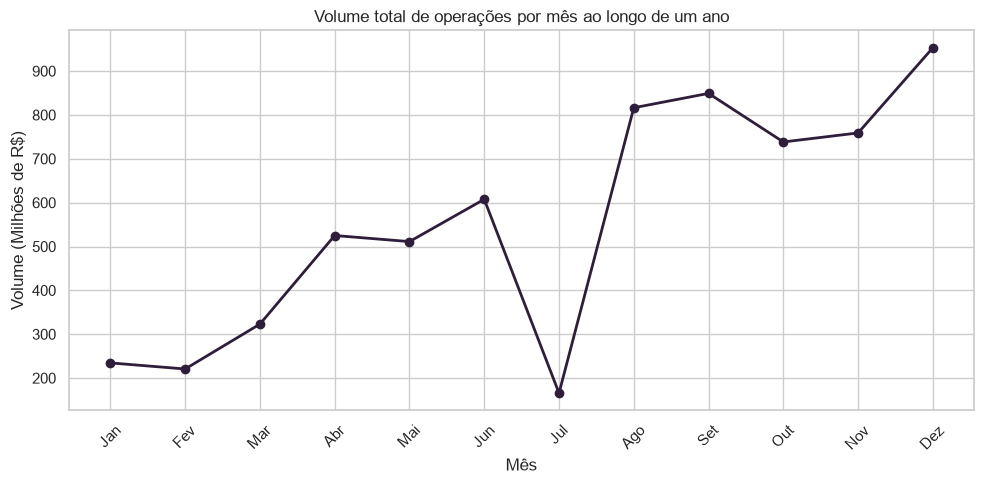

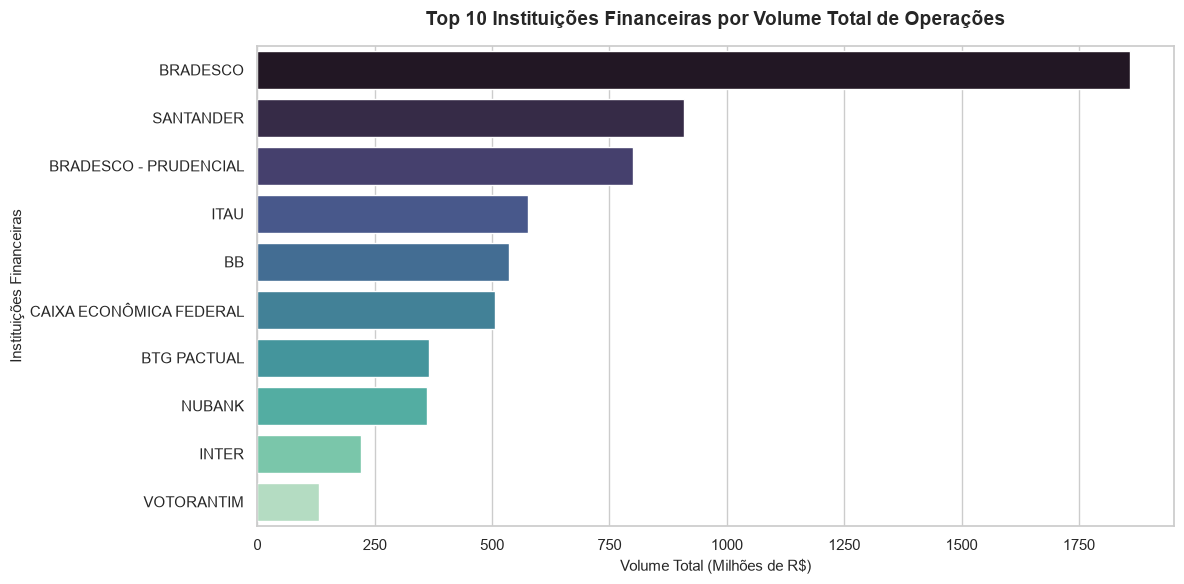

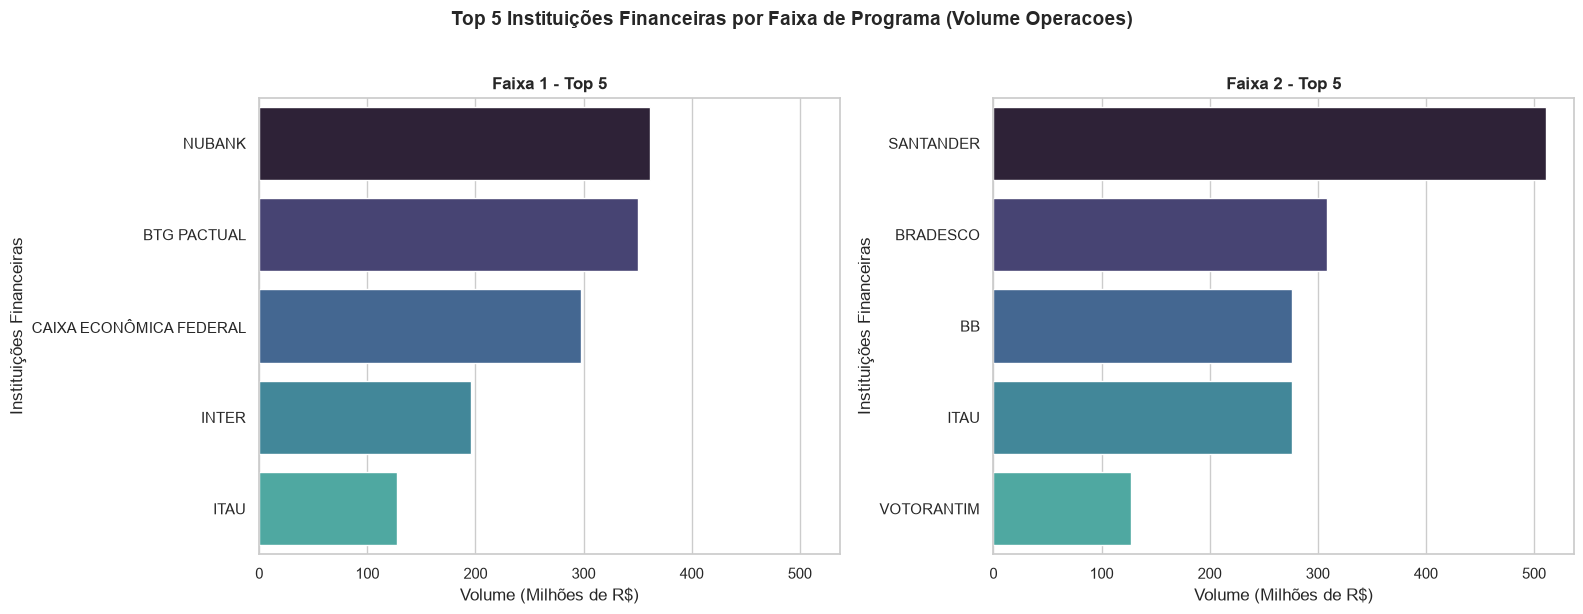

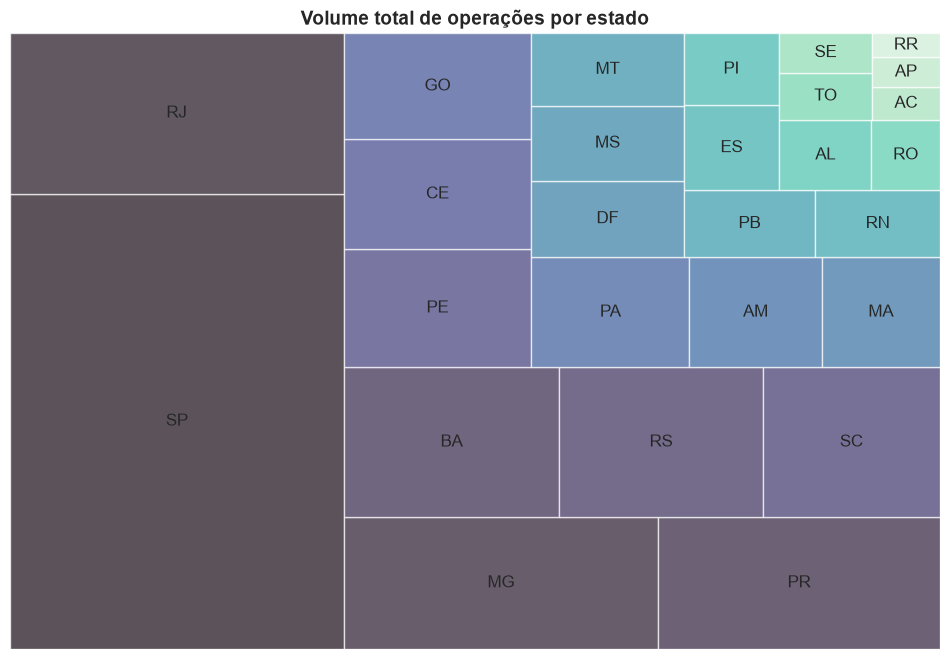

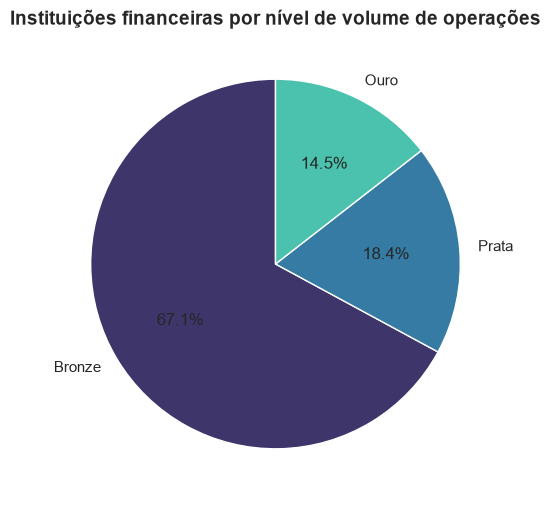

In [81]:
def line_plot_by_month(df, metric_column, output_directory="../outputs/plots"):
    """
    Gera e salva um gráfico de linha do volume total de operações por mês ao longo de um ano.
    Argumentos: df (pd.DataFrame): DataFrame a ser tratado.
                metric_column (str): Nome da coluna com os dados de volume.
                output_directory (str): Diretório onde a imagem será salva.
    Retorna:    None. A função exibe o gráfico na tela e o salva como um arquivo PNG.
    """
    months = [ "Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
    fig, ax = plt.subplots(figsize=(10, 5))
    by_month = df.groupby("MES")[metric_column].sum().reset_index(name="volume_total")
    by_month["volume_milhoes"] = by_month["volume_total"] / 1_000_000
    ax.plot(by_month["MES"], by_month["volume_milhoes"], marker= "o" , linewidth= 2 )
    ax.set_title("Volume total de operações por mês ao longo de um ano")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Volume (Milhões de R$)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months, rotation= 45)
    fig.tight_layout()
    os.makedirs(output_directory, exist_ok= True)
    fig.savefig(f"{output_directory}/volume_por_mes.png", dpi= 150)
    plt.show()
    plt.close()

def bar_plot_top_agents(df, agent_column, metric_column, top_n=10, output_directory="../outputs/plots", agent_label=None, metric_label=None):
    """
    Gera e salva um gráfico de barras do top N instituições financeiras por volume total de operações. Nesta função utilizei parâmetros agent_columns, metric_column, agent_label e metric_label na tentativa de deixar o código mais reutilizável.
    Argumentos: df (pd.DataFrame): DataFrame a ser tratado.
                agent_column (str): Nome da coluna que aqui representa as instituições financeiras.
                metric_column (str): Nome da coluna com os dados de volume.
                top_n (int): Número de instituições a serem exibidas no gráfico (padrão: 10).
                output_directory (str): Diretório onde a imagem será salva.
                agent_label (str): Etiqueta para as instituições financeiras a ser usado no gráfico (opcional).
                metric_label (str): Etiqueta para o volume de operações a ser usado no gráfico (opcional).
    Retorna:    None
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    top_agents = df.groupby(agent_column)[metric_column].sum().reset_index(name="volume_total")
    top_agents = top_agents.sort_values("volume_total", ascending=False).head(top_n)
    top_agents["volume_milhoes"] = top_agents["volume_total"] / 1_000_000
    sns.barplot(data=top_agents, x="volume_milhoes", y=agent_column, ax=ax, hue=agent_column, palette="mako")
    ax.set_title(f"Top {top_n} {agent_label} por {metric_label} de Operações", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Volume Total (Milhões de R$)", fontsize=11)
    ax.set_ylabel(f"{agent_label}", fontsize=11)
    fig.tight_layout()
    os.makedirs(output_directory, exist_ok= True)
    filename = f"top_{agent_column.lower()}_por_{metric_column.lower()}.png"
    fig.savefig(f"{output_directory}/{filename}", dpi=150)
    plt.show()
    plt.close()

def bar_plot_top_agents_by_type(df, type_column, agent_column, metric_column, top_n=3, output_directory="../outputs/plots", agent_label=None):
    """
    Gera e salva gráficos de barras lado a lado do top N instituições financeiras por volume total de operações, segmentadas pelas faixas 1 e 2 do programa (TIPO_DESENROLA).
    Argumentos: df (pd.DataFrame): DataFrame a ser tratado.
                type_column (str): Nome da coluna que categórica de agrupamento de cada gráfico (ex: TIPO_DESENROLA).
                agent_column (str): Nome da coluna que representa as instituições financeiras.
                metric_column (str): Nome da coluna com os dados de volume.
                top_n (int): Número de instituições a serem exibidas em cada gráfico (padrão: 3).
                output_directory (str): Diretório onde a imagem será salva.
                agent_label (str): Etiqueta para as instituições financeiras a ser usado no gráfico (opcional).
    Retorna:    None
    """
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), sharex=True)
    
    df_grouped = df.groupby([type_column, agent_column])[metric_column].sum().reset_index(name="volume_total")
    df_grouped["volume_milhoes"] = df_grouped["volume_total"] / 1_000_000

    data_type_1 = df_grouped[df_grouped[type_column] == 1].sort_values("volume_milhoes", ascending=False).head(top_n)
    sns.barplot(data=data_type_1, x="volume_milhoes", y=agent_column, ax=ax1, hue=agent_column, legend=False)
    ax1.set_title(f"Faixa 1 - Top {top_n}", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Volume (Milhões de R$)")
    ax1.set_ylabel(f"{agent_label}")

    data_type_2 = df_grouped[df_grouped[type_column] == 2].sort_values("volume_milhoes", ascending=False).head(top_n)
    sns.barplot(data=data_type_2, x="volume_milhoes", y=agent_column, ax=ax2, hue=agent_column, legend=False)
    ax2.set_title(f"Faixa 2 - Top {top_n}", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Volume (Milhões de R$)")
    ax2.set_ylabel(f"{agent_label}")

    fig.suptitle(f"Top {top_n} {agent_label} por Faixa de Programa ({metric_column.replace('_', ' ').title()})", fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    os.makedirs(output_directory, exist_ok=True)
    filename = f"top_{agent_column.lower()}_lado_a_lado_por_{metric_column.lower()}.png"
    fig.savefig(f"{output_directory}/{filename}", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

def treemap_by_state(df, state_column="UNIDADE_FEDERACAO", metric_column="VOLUME_OPERACOES", output_directory="../outputs/plots"):
    """
    Gera e salva um um gráfico de mapa de árvore (treemap) mostrando o volume total de operações por estado.
    Argumentos: df (pd.DataFrame): DataFrame a ser tratado.
                state_column (str): Nome da coluna que representa os estados (padrão: "UNIDADE_FEDERACAO").
                metric_column (str): Nome da coluna com os dados de volume.
                output_directory (str): Diretório onde a imagem será salva.
    Retorna:    None
    """
    df_state = df.groupby(state_column)[metric_column].sum().reset_index(name="volume_total")
    df_state = df_state.sort_values("volume_total", ascending=False)
    fig, ax = plt.subplots(figsize=(12, 8))
    squarify.plot(sizes=df_state["volume_total"], label=df_state[state_column], alpha=0.7, color=sns.color_palette("mako", len(df_state)))
    ax.set_title(f"Volume total de operações por estado", fontsize=14, fontweight="bold")
    ax.axis('off')
    os.makedirs(output_directory, exist_ok=True)
    filename = f"treemap_{metric_column.lower()}_por_{state_column.lower()}.png"
    fig.savefig(f"{output_directory}/{filename}", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

def pie_chart_institutions_tiered(df, tier_column="TIER", output_directory="../outputs/plots"):
    """
    Gera e salva um gráfico de pizza mostrando a distribuição percentual das instituições financeiras por Tier de volume de operações(Ouro, Prata, Bronze).
    Argumentos: df (pd.DataFrame): DataFrame contendo a classificação das instituições (gerado pela função tier_institutions_by_volume).
                tier_column (str): O nome da coluna que contém a classificação em Tiers. O padrão é "TIER".
                output_directory (str): O caminho da pasta onde o arquivo de imagem do gráfico será salvo. O padrão é "../outputs/plots".
    Retorna:    None
    """
    tier_counts = df[tier_column].value_counts()
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(
        tier_counts, 
        labels=tier_counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=sns.color_palette("mako", len(tier_counts))
    )
    ax.set_title("Instituições financeiras por nível de volume de operações", fontsize=14, fontweight="bold")
    os.makedirs(output_directory, exist_ok=True)
    filename = f"pie_chart_institutions_tiered.png"
    fig.savefig(f"{output_directory}/{filename}", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


sns.set_theme(style="whitegrid", palette="mako") 
line_plot_by_month(df, "VOLUME_OPERACOES", output_directory="../outputs/plots")
bar_plot_top_agents(
    df,
    "NOME_CONGLOMERADO_FINANCEIRO",
    "VOLUME_OPERACOES",
    top_n=10,
    output_directory="../outputs/plots",
    agent_label= "Instituições Financeiras",
    metric_label= "Volume Total")
bar_plot_top_agents_by_type(
    df,
    "TIPO_DESENROLA",
    "NOME_CONGLOMERADO_FINANCEIRO",
    "VOLUME_OPERACOES",
    top_n=5,
    output_directory="../outputs/plots",
    agent_label="Instituições Financeiras"
)
treemap_by_state(
    df,
    "UNIDADE_FEDERACAO",
    "VOLUME_OPERACOES",
    output_directory="../outputs/plots"
)
pie_chart_institutions_tiered(
    institutions_tiered,
    tier_column="TIER",
    output_directory="../outputs/plots"
)

### 10. Exportar resultados

In [82]:
def export_results(metrics, institutions_tiered, stats):
    """
    Exporta os resultados das métricas calculadas para arquivos CSV e JSON.
    Argumentos: metrics (dict): Dicionário contendo os DataFrames das métricas calculadas.
                institutions_tiered (pd.DataFrame): DataFrame com as instituições financeiras segmentadas por volume de operações.
                stats (dict): Dicionário com as estatísticas calculadas para o ticket médio por operação.
    Retorna:    None. Os arquivos são salvos no diretório "../outputs/metrics".
    """
    output_directory = "../outputs/metrics"
    os.makedirs(output_directory, exist_ok=True)

    # Exporta cada métrica para um arquivo CSV separado:
    for key, df_metric in metrics.items():
        metrics_path = os.path.join(output_directory, f"{key}.csv")
        df_metric.to_csv(metrics_path, index=False, encoding="utf-8-sig")
        logging.info(f"Métrica {key} exportada para arquivo CSV.")

    # Exporta a segmentação de instituições financeiras por volume para um arquivo CSV:
    tiered_path = os.path.join(output_directory, "institutions_tiered.csv")
    institutions_tiered.to_csv(tiered_path, index=False, encoding="utf-8-sig")
    logging.info("Segmentação de instituições financeiras por volume exportada para arquivo CSV.")

    # Exporta as estatísticas de ticket médio para um arquivo JSON:
    serializable_stats = {key: round(float(value), 2) for key, value in stats.items()}
    stats_path = os.path.join(output_directory, "ticket_medio_stats.json")
    with open(stats_path, "w", encoding="utf-8") as file:
        json.dump(serializable_stats, file, indent=2, ensure_ascii=False)
    logging.info("Estatísticas de ticket médio exportadas para arquivo JSON.")

    # Verificação de leitura dos arquivos exportados:
    with open(stats_path, encoding="utf-8") as file:
        read = json.load(file)
    logging.info(f"Leitura de volta do arquivo JSON de estatísticas de ticket médio:\n{json.dumps(read, indent=2, ensure_ascii=False)}")

export_results(metrics, institutions_tiered, stats)

INFO - Métrica volume_por_mes exportada para arquivo CSV.
INFO - Métrica numero_por_mes exportada para arquivo CSV.
INFO - Métrica volume_por_estado exportada para arquivo CSV.
INFO - Métrica volume_por_instituicao exportada para arquivo CSV.
INFO - Métrica conglomerado_por_tipo exportada para arquivo CSV.
INFO - Segmentação de instituições financeiras por volume exportada para arquivo CSV.
INFO - Estatísticas de ticket médio exportadas para arquivo JSON.
INFO - Leitura de volta do arquivo JSON de estatísticas de ticket médio:
{
  "mean": 7576.24,
  "std": 25805.85,
  "median": 1166.73,
  "percentile_25": 230.88,
  "percentile_75": 3662.4
}


### 11. Salvar o dataset final

In [83]:
os.makedirs( "data/final" , exist_ok= True )
df.to_csv( "data/final/dados_desenrola_final.csv" , index= False )
logging.info("Dataset final salvo em 'data/final/dados_desenrola_final.csv'")

INFO - Dataset final salvo em 'data/final/dados_desenrola_final.csv'
